In [4]:
import pandas as pd
df = pd.read_csv("heart.csv")
print(df.head())
print(df["target"].value_counts())

   age  sex  cp  trestbps  chol  fbs  thalach  exang  oldpeak  ca  target
0   10    0   2       122   100    1       67      1      3.2   0       0
1   23    1   3       363   200    0       89      1      2.7   0       1
2   34    1   0       353   150    1       56      1      4.5   0       2
3   56    1   2       678   250    1       98      0      2.9   0       0
4   76    0   2       899   300    0       95      0      1.5   0       1
1    5
0    4
2    1
Name: target, dtype: int64


In [5]:
x = df.drop("target",axis = 1)
y = df["target"]
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(
x , y , test_size = 0.2,random_state = 42)

In [6]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
pred = model.predict(x_test)
print(pred[:10])

[1 0]


C:\Users\ITLAB\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.metrics import(
accuracy_score, confusion_matrix, precision_score, recall_score, f1_score)
acc = accuracy_score(y_test,pred)
cm = confusion_matrix(y_test,pred)
prec = precision_score(y_test,pred)
rec = recall_score(y_test,pred)
f1 = f1_score(y_test,pred)
print(acc,prec,rec,f1)
print(cm)

0.5 1.0 0.5 0.6666666666666666
[[0 0]
 [1 1]]


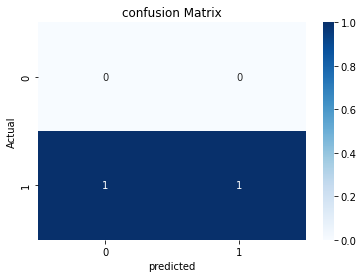

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("confusion Matrix")
plt.show()

In [14]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(x_train, y_train)
pred_knn = knn.predict(x_test)
print(accuracy_score(y_test, pred_knn))

0.5


In [16]:
for k in [1, 3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(x_train, y_train)
    pred_k = knn.predict(x_test)
    acc_k = accuracy_score(y_test, pred_k)
    print("k=", k,"->Accuracy:",acc_k)    

k= 1 ->Accuracy: 0.5
k= 3 ->Accuracy: 0.5
k= 5 ->Accuracy: 0.5
k= 7 ->Accuracy: 0.0
